# Day 06 — Document Loaders & Text Splitting (hands-on)

Companion notebook to [`../notes.md`](../notes.md). Two parts:

- **Part 1 — the simple version.** Load a small text file, compare **fixed-size** vs **recursive** splitting, and see chunk overlap in real output. Fully offline.
- **Part 2 — the production version.** A robust ingestion pipeline run on a real 58-page research paper (text, tables, figures, OCR, error handling).

No API key needed for either part. Part 2 downloads one public PDF (~4.7 MB) the first time it runs, into a git-ignored folder.

In [1]:
from pathlib import Path

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter

DATA_PATH = Path("data/sample_article.txt")

C:\Users\ramu\AppData\Local\Temp\ipykernel_31596\1896677247.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


C:\Users\ramu\OneDrive\Desktop\Agentic-AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the document

A document loader turns a raw file into LangChain `Document` objects — each with `page_content` (the
text) and `metadata` (like where it came from). This is the same shape no matter what loader you use
(PDF, DOCX, webpage) — see `notes.md` Section 1.

In [2]:
loader = TextLoader(str(DATA_PATH), encoding="utf-8")
docs = loader.load()

print(f"Loaded {len(docs)} document(s)")
print("Metadata:", docs[0].metadata)
print("Total characters:", len(docs[0].page_content))
print()
print(docs[0].page_content)

Loaded 1 document(s)
Metadata: {'source': 'data\\sample_article.txt'}
Total characters: 886

Paris is the capital of France. It is known for the Eiffel Tower, which was completed in 1889 and stands about 330 meters tall. Millions of tourists visit every year to see its museums, architecture, and cafes along the Seine.

The Louvre Museum, located in the heart of Paris, is the world's largest art museum. It houses the Mona Lisa, painted by Leonardo da Vinci, along with thousands of other works spanning centuries of human history.

France has a temperate climate with warm summers and mild winters. Agriculture remains important to the French economy, particularly wine production in regions like Bordeaux and Burgundy, which are famous worldwide for their vineyards.

Paris is also a major center for fashion and cuisine. Many of the world's leading fashion houses were founded there, and French cooking techniques form the basis of much of modern Western culinary training.



## 2. Fixed-size splitting — cuts wherever the character count lands

`CharacterTextSplitter` with an empty separator just cuts every N characters, no matter what's there.
Watch the start/end of these chunks — they cut mid-word.

In [3]:
fixed_splitter = CharacterTextSplitter(separator="", chunk_size=120, chunk_overlap=0)
fixed_chunks = fixed_splitter.split_text(docs[0].page_content)

print(f"{len(fixed_chunks)} chunks\n")
for i, chunk in enumerate(fixed_chunks):
    print(f"--- chunk {i} ({len(chunk)} chars) ---")
    print(chunk)
    print()

8 chunks

--- chunk 0 (120 chars) ---
Paris is the capital of France. It is known for the Eiffel Tower, which was completed in 1889 and stands about 330 meter

--- chunk 1 (120 chars) ---
s tall. Millions of tourists visit every year to see its museums, architecture, and cafes along the Seine.

The Louvre M

--- chunk 2 (120 chars) ---
useum, located in the heart of Paris, is the world's largest art museum. It houses the Mona Lisa, painted by Leonardo da

--- chunk 3 (119 chars) ---
Vinci, along with thousands of other works spanning centuries of human history.

France has a temperate climate with wa

--- chunk 4 (120 chars) ---
rm summers and mild winters. Agriculture remains important to the French economy, particularly wine production in region

--- chunk 5 (119 chars) ---
s like Bordeaux and Burgundy, which are famous worldwide for their vineyards.

Paris is also a major center for fashion

--- chunk 6 (120 chars) ---
and cuisine. Many of the world's leading fashion houses were fou

Notice chunk 0 above ends mid-word (something like `...stands about 330 meter`) and the next chunk
picks up wherever the character count happened to land — not at a word or sentence boundary. This is
exactly the "cuts mid-word" problem from `notes.md` Section 2.

## 3. Recursive splitting — tries natural boundaries first

`RecursiveCharacterTextSplitter` tries paragraph breaks, then sentence breaks, then word breaks, before
resorting to a hard cut. Same source text, same `chunk_size`, much more readable chunks.

In [4]:
recursive_splitter = RecursiveCharacterTextSplitter(chunk_size=120, chunk_overlap=20)
recursive_chunks = recursive_splitter.split_text(docs[0].page_content)

print(f"{len(recursive_chunks)} chunks\n")
for i, chunk in enumerate(recursive_chunks):
    print(f"--- chunk {i} ({len(chunk)} chars) ---")
    print(chunk)
    print()

10 chunks

--- chunk 0 (114 chars) ---
Paris is the capital of France. It is known for the Eiffel Tower, which was completed in 1889 and stands about 330

--- chunk 1 (117 chars) ---
stands about 330 meters tall. Millions of tourists visit every year to see its museums, architecture, and cafes along

--- chunk 2 (26 chars) ---
and cafes along the Seine.

--- chunk 3 (117 chars) ---
The Louvre Museum, located in the heart of Paris, is the world's largest art museum. It houses the Mona Lisa, painted

--- chunk 4 (113 chars) ---
Mona Lisa, painted by Leonardo da Vinci, along with thousands of other works spanning centuries of human history.

--- chunk 5 (119 chars) ---
France has a temperate climate with warm summers and mild winters. Agriculture remains important to the French economy,

--- chunk 6 (118 chars) ---
the French economy, particularly wine production in regions like Bordeaux and Burgundy, which are famous worldwide for

--- chunk 7 (30 chars) ---
worldwide for their vineyards

## 4. Seeing chunk overlap in real output

`chunk_overlap=20` means each chunk repeats a little of the previous chunk's ending. Let's print the
tail of chunk 0 next to the head of chunk 1 to see the shared text directly.

In [5]:
print("End of chunk 0:  ", repr(recursive_chunks[0][-35:]))
print("Start of chunk 1: ", repr(recursive_chunks[1][:35]))
print()
print("That overlap is exactly what protects a sentence sitting right at a chunk boundary")
print("from being lost — it still appears whole in at least one of the two chunks.")

End of chunk 0:   'pleted in 1889 and stands about 330'
Start of chunk 1:  'stands about 330 meters tall. Milli'

That overlap is exactly what protects a sentence sitting right at a chunk boundary
from being lost — it still appears whole in at least one of the two chunks.


## 5. A cleaner view: chunk size matched to paragraph length

If `chunk_size` comfortably fits a whole paragraph, recursive splitting aligns almost perfectly to
paragraph boundaries — no mid-sentence cuts at all.

In [6]:
clean_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=40)
clean_chunks = clean_splitter.split_text(docs[0].page_content)

print(f"{len(clean_chunks)} chunks\n")
for i, chunk in enumerate(clean_chunks):
    print(f"--- chunk {i} ({len(chunk)} chars) ---")
    print(chunk)
    print()

4 chunks

--- chunk 0 (226 chars) ---
Paris is the capital of France. It is known for the Eiffel Tower, which was completed in 1889 and stands about 330 meters tall. Millions of tourists visit every year to see its museums, architecture, and cafes along the Seine.

--- chunk 1 (212 chars) ---
The Louvre Museum, located in the heart of Paris, is the world's largest art museum. It houses the Mona Lisa, painted by Leonardo da Vinci, along with thousands of other works spanning centuries of human history.

--- chunk 2 (235 chars) ---
France has a temperate climate with warm summers and mild winters. Agriculture remains important to the French economy, particularly wine production in regions like Bordeaux and Burgundy, which are famous worldwide for their vineyards.

--- chunk 3 (206 chars) ---
Paris is also a major center for fashion and cuisine. Many of the world's leading fashion houses were founded there, and French cooking techniques form the basis of much of modern Western culinary tr

## Try it yourself

- Change `chunk_size` and `chunk_overlap` above and re-run — watch how the chunk count and boundaries
  change.
- Swap in your own `.txt` file in `data/` and re-run Section 1 onward.
- If you have a PDF handy, try `PyPDFLoader` or `PyMuPDFLoader` (both installed) in place of
  `TextLoader`, and compare the `metadata` you get back (page numbers show up here).

---
# Part 2 — A production-style ingestion pipeline (on a real, messy PDF)

Part 1 used a tiny, clean `.txt` file. Real documents aren't like that. This part runs a pipeline on
the **DeepSeek-V4 technical report** (58 pages, from arXiv) — a genuinely hard case: long, full of
figures and tables, with a huge author list in its metadata.

**What "production-grade" means here** — one pipeline that handles every case it will meet:

| Case | How it's handled |
|---|---|
| Normal text pages | PyMuPDF text extraction, in reading order, with page numbers |
| Scanned / image-only pages | Detect "no text layer + a big picture" → fall back to OCR (Tesseract) |
| Tables with ruling lines | PyMuPDF's table finder, then a **quality check** before trusting it |
| Tables *without* ruling lines (common in papers) | Rebuild rows from word positions, anchored on the "Table N" caption |
| Raster images (JPEG/PNG) | Extract and save them, skipping decorative logos |
| Vector figures (charts drawn as shapes) | Detect drawing clusters and render them to PNG, keep the caption |
| Bad files (corrupted, wrong type) | One bad file must not crash the whole batch |
| Messy PDF metadata | Keep only a small whitelist of fields |

It downloads the PDF once (~4.7 MB) into a git-ignored folder, so it needs internet the first time only.

In [7]:
import hashlib
import logging
import re
import shutil
import time
import urllib.request
from collections import Counter
from pathlib import Path

import pymupdf
import pytesseract
from IPython.display import Image as IPImage
from IPython.display import display
from langchain_core.documents import Document
from PIL import Image

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s", force=True)
log = logging.getLogger("ingest")

PDF_URL = "https://arxiv.org/pdf/2606.19348"  # DeepSeek-V4 technical report
DOWNLOAD_DIR = Path("data/downloads")
EXTRACT_DIR = Path("data/extracted")
PDF_PATH = DOWNLOAD_DIR / "deepseek_v4.pdf"

## 2.1 Get the document (download once, then reuse the cached copy)

A production loader never assumes the file is already there — and it checks that what it got is really
a PDF (an error page saved as `.pdf` is a classic silent failure).

In [8]:
def ensure_pdf(url: str, dest: Path) -> Path:
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and dest.read_bytes()[:5] == b"%PDF-":
        log.info("Using cached file: %s (%.1f MB)", dest.name, dest.stat().st_size / 1e6)
        return dest
    log.info("Downloading %s ...", url)
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request, timeout=90) as response:
        data = response.read()
    if data[:5] != b"%PDF-":
        raise ValueError("Downloaded content is not a PDF (got an HTML error page?)")
    dest.write_bytes(data)
    log.info("Saved %s (%.1f MB)", dest.name, len(data) / 1e6)
    return dest


ensure_pdf(PDF_URL, PDF_PATH)

INFO | Using cached file: deepseek_v4.pdf (4.7 MB)


WindowsPath('data/downloads/deepseek_v4.pdf')

Let's peek at the document — and at its **metadata**, which is a good example of why you don't copy
everything blindly.

In [9]:
peek = pymupdf.open(PDF_PATH)
print("Pages:", len(peek))
print("Title:", peek.metadata["title"])
print("Length of the 'author' field:", len(peek.metadata["author"]), "characters")
print("Start of it:", peek.metadata["author"][:80], "...")
peek.close()

Pages: 58
Title: DeepSeek-V4: Towards Highly Efficient Million-Token Context Intelligence
Length of the 'author' field: 3834 characters
Start of it: DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao ...


That author field is thousands of characters long. If you attached it to *every chunk* as metadata,
you'd bloat your vector store and pollute filters. So our pipeline keeps a **small whitelist**
(title, file id, page) instead of copying the whole PDF metadata.

## 2.2 Set up OCR (for scanned pages)

Tesseract is a separate program (not a pip package), so the code looks for it in the usual places and
**turns OCR off gracefully** if it can't find it — instead of crashing.

In [10]:
def find_tesseract():
    found = shutil.which("tesseract")
    if found:
        return found
    for candidate in (
        r"C:\Program Files\Tesseract-OCR\tesseract.exe",
        r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe",
        "/usr/bin/tesseract",
        "/usr/local/bin/tesseract",
        "/opt/homebrew/bin/tesseract",
    ):
        if Path(candidate).exists():
            return candidate
    return None


TESSERACT = find_tesseract()
if TESSERACT:
    pytesseract.pytesseract.tesseract_cmd = TESSERACT
    log.info("OCR enabled (Tesseract found at %s)", TESSERACT)
else:
    log.warning("Tesseract not found — scanned pages will be flagged but not OCR'd")

INFO | OCR enabled (Tesseract found at C:\Program Files\Tesseract-OCR\tesseract.exe)


## 2.3 The extractors — one small function per job

### Tables, level 1: tables with ruling lines — extract, then **quality-check**

PyMuPDF can detect tables, but on real papers it also "finds" tables in charts and diagrams. So every
candidate must pass a simple gate: enough rows/columns, mostly filled cells, short cells (real table
cells are short), and some numbers. Anything that fails is **not thrown away** — its text simply stays
in the normal page text.

In [11]:
def table_quality(rows):
    cells = [c for row in rows for c in row]
    if not cells:
        return {"fill": 0.0, "avg_len": 0.0, "numeric": 0.0}
    filled = [str(c) for c in cells if c and str(c).strip()]
    return {
        "fill": len(filled) / len(cells),
        "avg_len": sum(len(c) for c in filled) / max(1, len(filled)),
        "numeric": sum(any(ch.isdigit() for ch in c) for c in filled) / max(1, len(filled)),
    }


def table_passes_gate(rows, min_rows=3, min_cols=2, min_fill=0.6, max_avg_len=40, min_numeric=0.2):
    if len(rows) < min_rows or not rows or len(rows[0]) < min_cols:
        return False
    q = table_quality(rows)
    return q["fill"] >= min_fill and q["avg_len"] <= max_avg_len and q["numeric"] >= min_numeric


def extract_ruled_tables(page):
    """Return (accepted, rejected_count). accepted = list of (rect, markdown)."""
    accepted, rejected = [], 0
    for table in page.find_tables().tables:
        if table_passes_gate(table.extract()):
            try:
                accepted.append((pymupdf.Rect(table.bbox), table.to_markdown()))
                continue
            except Exception:
                pass
        rejected += 1
    return accepted, rejected

### Tables, level 2: tables **without** ruling lines (very common in papers)

Most benchmark tables in research papers have no grid lines, so level 1 finds nothing. Here's the
fallback — rebuild the table from **word positions**, anchored on its caption:

```
words with x/y positions  →  group into lines by y  →  split each line into cells at big x-gaps
  "AGIEval (EM)"  "0-shot"  "80.1"  "82.6"  "83.1"   →   | AGIEval (EM) | 0-shot | 80.1 | 82.6 | 83.1 |
```

The table starts right under a caption like `Table 1 | Comparison among...` and ends when a long
paragraph line begins. This is a **heuristic** — data rows come out well, header rows are messier — so
we label these tables `extraction_method="caption_layout"` (medium confidence) in the metadata.

In [12]:
CAPTION_RE = re.compile(r"^\s*(Table|Figure|Fig\.)\s+\d+\s*[|:.\u2013\-]")


def is_caption(text: str, kind: str) -> bool:
    match = CAPTION_RE.match(text)
    return bool(match) and match.group(1).lower().startswith(kind.lower())


def group_lines(words, y_tol=3.0):
    """Group words (x0, y0, x1, y1, text, ...) into visual lines by their y position."""
    words = sorted(words, key=lambda w: (w[1], w[0]))
    lines, current, anchor = [], [], None
    for w in words:
        if anchor is None or abs(w[1] - anchor) <= y_tol:
            current.append(w)
            anchor = w[1] if anchor is None else anchor
        else:
            lines.append(current)
            current, anchor = [w], w[1]
    if current:
        lines.append(current)
    return lines


def split_cells(line_words, gap=14.0):
    """Split one line into cells wherever there is a big horizontal gap."""
    cells, current, last_x1 = [], [], None
    for w in sorted(line_words, key=lambda w: w[0]):
        if last_x1 is not None and w[0] - last_x1 > gap:
            cells.append(" ".join(current))
            current = []
        current.append(w[4])
        last_x1 = w[2]
    cells.append(" ".join(current))
    return cells


def extract_captioned_tables(page, skip_rects=()):
    """Rebuild borderless tables under 'Table N |' captions. Returns list of (rect, markdown, caption)."""
    text_blocks = [b for b in page.get_text("blocks") if b[6] == 0]
    captions = sorted((b for b in text_blocks if is_caption(b[4], "Table")), key=lambda b: b[1])
    stop_ys = sorted(b[1] for b in text_blocks if is_caption(b[4], "Table") or is_caption(b[4], "Figure"))
    all_words = page.get_text("words")
    found = []

    for cap in captions:
        cap_rect = pymupdf.Rect(cap[:4])
        if any(cap_rect.intersects(r) for r in skip_rects):
            continue  # a ruled table already covers this one
        stop_y = min([y for y in stop_ys if y > cap_rect.y1 + 5] + [page.rect.y1 - 45])
        words = [w for w in all_words if w[1] >= cap_rect.y1 + 1 and w[3] <= stop_y]

        rows, body_rows = [], 0
        for line in group_lines(words):
            cells = split_cells(line)
            text = " ".join(cells)
            looks_tabular = len(cells) >= 3 or (len(cells) == 2 and any(ch.isdigit() for ch in text))
            looks_like_paragraph = len(cells) == 1 and len(text) > 60
            if body_rows >= 3 and looks_like_paragraph:
                break  # the table is over, normal text has started
            body_rows += looks_tabular
            rows.append((line, cells))
        if body_rows < 3:
            continue  # not really a table (e.g. a text box) — leave it in the page text

        ncols = max(len(cells) for _, cells in rows)
        matrix = []
        for _, cells in rows:
            missing = ncols - len(cells)
            # keep the row label first, pad the gap after it so numbers stay right-aligned
            matrix.append(cells[:1] + [""] * missing + cells[1:] if missing > 0 else cells)
        if table_quality(matrix)["numeric"] < 0.2:
            continue  # mostly words, not data — leave it in the page text

        rect = pymupdf.Rect(cap[:4])
        for line, _ in rows:
            for w in line:
                rect |= pymupdf.Rect(w[:4])
        lines_md = ["| " + " | ".join(matrix[0]) + " |", "|" + "---|" * ncols]
        lines_md += ["| " + " | ".join(row) + " |" for row in matrix[1:]]
        found.append((rect, "\n".join(lines_md), " ".join(cap[4].split())))
    return found

### Text: reading order, with table regions removed

Extracting text *blocks* (instead of one big string) lets us skip blocks that sit inside a table we
already captured separately — so the same numbers aren't stored twice.

In [13]:
def extract_text(page, table_rects):
    kept = []
    for x0, y0, x1, y1, text, _block_no, block_type in page.get_text("blocks", sort=True):
        if block_type != 0:  # 0 = text block, 1 = image block
            continue
        if any(pymupdf.Rect(x0, y0, x1, y1).intersects(r) for r in table_rects):
            continue
        if text.strip():
            kept.append(text.strip())
    return "\n\n".join(kept)

### Images and figures — two different problems

- **Raster images** (embedded JPEG/PNG): extract the original bytes. Skip **decorative** ones — judged by
  how big they're *displayed*, not just their pixel size (a 1800px logo shown at postage-stamp size is
  still a logo).
- **Vector figures** (charts drawn from lines and shapes — very common in papers): there's no image to
  extract, so we find clusters of drawing commands and **render that region** to a PNG.

We also grab the nearby **caption** ("Figure 3 | ...") so each figure becomes searchable text.

In [14]:
def find_caption(page, rect, max_gap=70):
    best = None
    for x0, y0, x1, y1, text, _n, block_type in page.get_text("blocks"):
        if block_type != 0 or not is_caption(text, "Figure"):
            continue
        gap = y0 - rect.y1  # figure captions sit just below the figure
        if -5 <= gap <= max_gap and (best is None or gap < best[0]):
            best = (gap, " ".join(text.split()))
    return best[1] if best else ""


def extract_raster_images(doc, page, page_no, out_dir, min_side_px=200, min_display_area=20000):
    found = []
    for idx, item in enumerate(page.get_images(full=True), start=1):
        info = doc.extract_image(item[0])
        if min(info["width"], info["height"]) < min_side_px:
            continue
        try:
            rect = page.get_image_bbox(item)
        except Exception:
            rect = None
        if rect is not None and rect.width * rect.height < min_display_area:
            continue  # displayed tiny -> decorative logo/icon
        path = out_dir / f"page{page_no:03d}_img{idx}.{info['ext']}"
        path.write_bytes(info["image"])
        found.append((path, rect, info["width"], info["height"]))
    return found


def render_vector_figures(page, page_no, out_dir, skip_rects, min_w=120, min_h=90, dpi=130, pad=6):
    found = []
    for idx, rect in enumerate(page.cluster_drawings(), start=1):
        if rect.width < min_w or rect.height < min_h:
            continue
        if any(rect.intersects(r) for r in skip_rects if r is not None):
            continue  # already captured as a raster image
        clip = (rect + (-pad, -pad, pad, pad)) & page.rect
        path = out_dir / f"page{page_no:03d}_fig{idx}.png"
        page.get_pixmap(clip=clip, dpi=dpi).save(path)
        found.append((path, rect))
    return found

### OCR fallback for scanned pages

A "scanned" PDF page has no text layer — just a picture of a page. So the test is **two things together**:
almost no text, *and* a picture covering most of the page. (A page that's just a big chart with a short
caption has little text too, but it isn't a scan — the picture-coverage check keeps us from OCR'ing it.)

In [15]:
def page_needs_ocr(page, min_chars=40, min_coverage=0.6):
    if len(page.get_text().strip()) >= min_chars:
        return False
    page_area = page.rect.width * page.rect.height
    covered = sum(pymupdf.Rect(info["bbox"]).width * pymupdf.Rect(info["bbox"]).height for info in page.get_image_info())
    return covered / page_area >= min_coverage


def ocr_page(page, dpi=200):
    pix = page.get_pixmap(dpi=dpi)
    image = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
    return pytesseract.image_to_string(image)

## 2.4 The main function — per-page error isolation

Every page is wrapped in its own `try/except`. If page 37 has something weird, we log it and keep
going — we don't lose the other 57 pages.

In [16]:
def ingest_pdf(pdf_path: Path, extract_dir: Path = EXTRACT_DIR):
    pdf_path = Path(pdf_path)
    doc = pymupdf.open(pdf_path)  # raises on corrupted files — the batch runner catches that
    if doc.needs_pass:
        raise PermissionError(f"{pdf_path.name} is password-protected")

    out_dir = extract_dir / pdf_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    file_id = hashlib.sha256(pdf_path.read_bytes()).hexdigest()[:12]  # lets you skip re-ingesting unchanged files
    base_meta = {
        "source": pdf_path.name,
        "file_id": file_id,
        "title": (doc.metadata or {}).get("title", "") or pdf_path.stem,
        "total_pages": len(doc),
    }

    docs, report = [], Counter()
    started = time.time()

    for page_no, page in enumerate(doc, start=1):
        try:
            # --- scanned page? -> OCR fallback, skip everything else (the page IS the image)
            if page_needs_ocr(page):
                report["pages_needing_ocr"] += 1
                if TESSERACT:
                    text = ocr_page(page).strip()
                    if text:
                        docs.append(Document(page_content=text, metadata={**base_meta, "page": page_no, "content_type": "ocr_text"}))
                        report["ocr_docs"] += 1
                else:
                    log.warning("Page %d looks scanned but OCR is unavailable", page_no)
                continue

            # --- tables: ruled first (high confidence), then caption-anchored (medium confidence)
            ruled, rejected = extract_ruled_tables(page)
            layout = extract_captioned_tables(page, skip_rects=[r for r, _ in ruled])
            report["tables_ruled"] += len(ruled)
            report["tables_caption_layout"] += len(layout)
            report["tables_rejected"] += rejected

            for t_idx, (rect, markdown) in enumerate(ruled, start=1):
                docs.append(Document(page_content=markdown, metadata={**base_meta, "page": page_no, "content_type": "table", "extraction_method": "ruled_table", "table_index": t_idx}))
            for t_idx, (rect, markdown, caption) in enumerate(layout, start=len(ruled) + 1):
                docs.append(Document(page_content=f"{caption}\n\n{markdown}", metadata={**base_meta, "page": page_no, "content_type": "table", "extraction_method": "caption_layout", "table_index": t_idx}))

            # --- normal text, without the regions already captured as tables
            table_rects = [r for r, _ in ruled] + [r for r, _, _ in layout]
            text = extract_text(page, table_rects)
            if text:
                docs.append(Document(page_content=text, metadata={**base_meta, "page": page_no, "content_type": "text"}))

            # --- raster images, then vector figures (each with its caption)
            rasters = extract_raster_images(doc, page, page_no, out_dir)
            for path, rect, w, h in rasters:
                caption = find_caption(page, rect) if rect else ""
                docs.append(Document(
                    page_content=caption or f"[Image on page {page_no}]",
                    metadata={**base_meta, "page": page_no, "content_type": "image", "image_path": str(path), "width": w, "height": h},
                ))
                report["raster_images"] += 1

            for path, rect in render_vector_figures(page, page_no, out_dir, [r for _, r, _, _ in rasters]):
                caption = find_caption(page, rect)
                docs.append(Document(
                    page_content=caption or f"[Figure on page {page_no}]",
                    metadata={**base_meta, "page": page_no, "content_type": "figure", "image_path": str(path)},
                ))
                report["vector_figures"] += 1

        except Exception as exc:  # one bad page must not sink the document
            report["pages_failed"] += 1
            log.error("Page %d failed: %r", page_no, exc)

    doc.close()
    report["pages"] = base_meta["total_pages"]
    report["seconds"] = round(time.time() - started, 1)
    return docs, dict(report)

## 2.5 Run it on the real paper

In [17]:
docs, report = ingest_pdf(PDF_PATH)

print("Ingestion report:")
for key, value in report.items():
    print(f"  {key:>22}: {value}")
print()
print("Documents produced, by content type:", dict(Counter(d.metadata["content_type"] for d in docs)))

Consider using the pymupdf_layout package for a greatly improved page layout analysis.


Ingestion report:
            tables_ruled: 0
   tables_caption_layout: 8
         tables_rejected: 45
          vector_figures: 20
           raster_images: 5
                   pages: 58
                 seconds: 6.0

Documents produced, by content type: {'text': 56, 'figure': 20, 'table': 8, 'image': 5}


Notice the report is itself a production feature — it tells you at a glance what was found, what was
rejected, and whether anything failed. Real pipelines log this for every file.

Now let's look at real output from each content type.

In [18]:
first_text = next(d for d in docs if d.metadata["content_type"] == "text")
print("A TEXT document (page", first_text.metadata["page"], ")")
print("metadata:", first_text.metadata)
print("content :", first_text.page_content[:300].replace("\n", " "), "...")

A TEXT document (page 1 )
metadata: {'source': 'deepseek_v4.pdf', 'file_id': '55b2d72f772a', 'title': 'DeepSeek-V4: Towards Highly Efficient Million-Token Context Intelligence', 'total_pages': 58, 'page': 1, 'content_type': 'text'}
content : DeepSeek-V4: Towards Highly Efficient Million-Token Context Intelligence  DeepSeek-AI research@deepseek.com  Abstract  We present a preview version of DeepSeek-V4 series, including two strong Mixture-of-  Experts (MoE) language models — DeepSeek-V4-Pro with 1.6T parameters (49B activated) and DeepSe ...


### Tables — what each level caught

In [19]:
table_docs = [d for d in docs if d.metadata["content_type"] == "table"]
print(f"Ruled tables kept: {report.get('tables_ruled', 0)}   |   caption-layout tables kept: {report.get('tables_caption_layout', 0)}"
      f"   |   ruled candidates rejected as false positives: {report.get('tables_rejected', 0)}")
print()
sample_table = next(d for d in table_docs if d.metadata["page"] == 28)
print("metadata:", {k: v for k, v in sample_table.metadata.items() if k in ("page", "content_type", "extraction_method")})
print()
print("\n".join(sample_table.page_content.split("\n")[:14]))

Ruled tables kept: 0   |   caption-layout tables kept: 8   |   ruled candidates rejected as false positives: 45

metadata: {'page': 28, 'content_type': 'table', 'extraction_method': 'caption_layout'}

Table 1 | Comparison among DeepSeek-V3.2-Base, DeepSeek-V4-Flash-Base, and DeepSeek-V4- Pro-Base. All models are evaluated in our internal framework and share the same evaluation setting. Scores with a gap not exceeding 0.3 are considered to be at the same level. The highest score in each row is in bold font, and the second is underlined.

| DeepSeek-V3.2 DeepSeek-V4-Flash DeepSeek-V4-Pro |  |  |  |  |
|---|---|---|---|---|
| Benchmark (Metric) |  |  |  | # Shots |
| Base |  |  | Base | Base |
| Architecture | - | MoE | MoE | MoE |
| # Activated Params | - | 37B | 13B | 49B |
| # Total Params | - | 671B | 284B | 1.6T |
| AGIEval (EM) | 0-shot | 80.1 | 82.6 | 83.1 |
| MMLU (EM) | 5-shot | 87.8 | 88.7 | 90.1 |
| MMLU-Redux (EM) | 5-shot | 87.5 | 89.4 | 90.8 |
| MMLU-Pro (EM) | 5-shot | 65.5

Read that carefully — it's an honest picture of heuristic table extraction:

- **Data rows are good.** `AGIEval (EM) | 0-shot | 80.1 | 82.6 | 83.1` is exactly what we want, and
  every number is there for retrieval.
- **Header rows are messy** (multi-line, spanning-column headers are hard for any heuristic).

That's why the metadata says `caption_layout` — downstream code can treat it as *medium confidence*.
The 45 ruled candidates the level-1 gate rejected were chart labels and diagrams, correctly refused.
And any table that neither method accepts (like text-only tables) simply stays inside the normal
page text, so nothing is silently lost.

### Figures — with captions as searchable text

In [20]:
fig_docs = [d for d in docs if d.metadata["content_type"] in ("image", "figure")]
print(f"{len(fig_docs)} figures/images extracted. A few examples:\n")
for d in fig_docs[:7]:
    m = d.metadata
    print(f"  page {m['page']:>2} | {m['content_type']:<6} | {Path(m['image_path']).name}")
    print(f"           caption: {d.page_content[:110]}")

25 figures/images extracted. A few examples:

  page  1 | figure | page001_fig2.png
           caption: Figure 1 | Left: benchmark performance of DeepSeek-V4-Pro-Max and its counterparts. Right: inference FLOPs and
  page  6 | figure | page006_fig1.png
           caption: Figure 2 | Overall architecture of DeepSeek-V4 series. We use hybrid CSA (Compressed Sparse Attention) and HCA
  page  9 | figure | page009_fig1.png
           caption: Figure 3 | Core architectures of CSA. It compresses the number of KV entries to 1
  page 11 | figure | page011_fig1.png
           caption: Figure 4 | Core architectures of HCA. It performs heavier compression, where the KV entries of 𝑚′ (≫𝑚) tokens 
  page 15 | figure | page015_fig2.png
           caption: Figure 5 | Illustration of our EP scheme with related works. Comet (Zhang et al., 2025b) overlaps Dispatch wit
  page 22 | figure | page022_fig1.png
           caption: Figure 6 | Illustration of the KV cache Layout for DeepSeek-V4. The KV cache is 

Each figure is now a `Document` whose text is its **caption** (so a text search can find it) and whose
metadata holds the **image path** (so an app — or a vision model — can show or read the actual image).
That's the standard pattern for multimodal RAG.

Let's actually look at two of them (shrunk so the notebook stays small):

figure on page 1: Figure 1 | Left: benchmark performance of DeepSeek-V4-Pro-Max and its counterparts. Right: inference


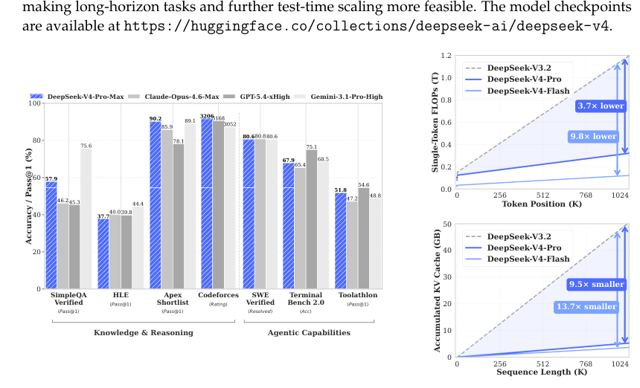

figure on page 6: Figure 2 | Overall architecture of DeepSeek-V4 series. We use hybrid CSA (Compressed Sparse Attentio


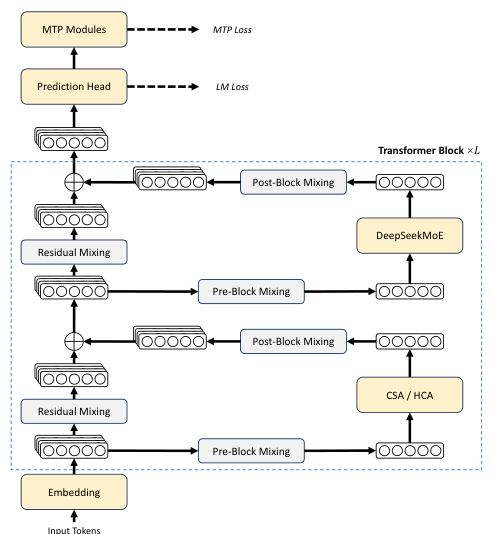

In [21]:
def to_thumbnail(path: Path, max_side=640) -> Path:
    img = Image.open(path)
    if img.mode in ("RGBA", "LA", "P"):
        img = img.convert("RGBA")
        background = Image.new("RGB", img.size, "white")
        background.paste(img, mask=img.split()[-1])
        img = background
    else:
        img = img.convert("RGB")
    img.thumbnail((max_side, max_side))
    thumb_dir = EXTRACT_DIR / "thumbs"
    thumb_dir.mkdir(parents=True, exist_ok=True)
    out = thumb_dir / f"{path.stem}.jpg"
    img.save(out, quality=78, optimize=True)
    return out


shown = [
    next(d for d in fig_docs if d.metadata["page"] == 1),   # Figure 1 (a vector chart, rendered)
    next(d for d in fig_docs if d.metadata["page"] == 6),   # Figure 2 (architecture diagram)
]
for d in shown:
    print(f"{d.metadata['content_type']} on page {d.metadata['page']}: {d.page_content[:100]}")
    display(IPImage(filename=str(to_thumbnail(Path(d.metadata["image_path"])))))

## 2.6 Scanned pages: does the OCR fallback really work?

The DeepSeek PDF has a text layer on every page, so OCR never triggered above. To *prove* the fallback
works, let's **simulate a scan**: render one real page to a picture, and rebuild a PDF that contains only
that picture — no text layer, exactly like a scanned document.

In [22]:
SCAN_PATH = EXTRACT_DIR / "simulated_scan.pdf"

source = pymupdf.open(PDF_PATH)
original_page = source[4]  # page 5
original_text = original_page.get_text()
pix = original_page.get_pixmap(dpi=150)

scan = pymupdf.open()
scan_page = scan.new_page(width=original_page.rect.width, height=original_page.rect.height)
scan_page.insert_image(scan_page.rect, pixmap=pix)
scan.save(SCAN_PATH)
scan.close()
source.close()

check = pymupdf.open(SCAN_PATH)
print("Text layer on the simulated scan:", repr(check[0].get_text().strip()), "<- empty, just like a real scan")
print("Looks scanned to our detector?  ", page_needs_ocr(check[0]))
check.close()

Text layer on the simulated scan: '' <- empty, just like a real scan
Looks scanned to our detector?   True


In [23]:
scan_docs, scan_report = ingest_pdf(SCAN_PATH)
print("Report:", scan_report)
ocr_doc = scan_docs[0]
print("Content type:", ocr_doc.metadata["content_type"])
print("\nOCR output (first 300 chars):")
print(ocr_doc.page_content[:300])

Report: {'pages_needing_ocr': 1, 'ocr_docs': 1, 'pages': 1, 'seconds': 2.0}
Content type: ocr_text

OCR output (first 300 chars):
By employing hybrid CSA and HCA, along with precision optimizations on computation
and storage, DeepSeek-V4 series achieve significantly lower inference FLOPs and a substantially
reduced KV cache size compared with DeepSeek-V3.2, especially in long-context settings. The
right part of Figure 1 demons


Quick sanity check — how close is the OCR text to the *real* text of that page?

In [24]:
import difflib


def normalize(s):
    return " ".join(s.split()).lower()


similarity = difflib.SequenceMatcher(None, normalize(original_text), normalize(ocr_doc.page_content)).ratio()
print(f"OCR text vs. original text similarity: {similarity:.1%}")

OCR text vs. original text similarity: 99.9%


High similarity means the fallback recovers the page's content. (This is a *clean* digital render, so
it's an easy case — real scans with noise, skew, or handwriting score lower.) OCR is never perfect,
especially with equations and special symbols, which is why the metadata marks it `ocr_text` — so you can
treat it with a little less trust than a native text layer.

## 2.7 A batch runner: one bad file must not crash the run

Real ingestion handles folders of mixed files. This runner picks a loader by file type, **skips
unsupported types**, and **catches failures per file** — so you get a clear list of what went wrong
instead of a crash at file 3 of 200.

It even reuses Part 1's simple `TextLoader` for `.txt` files.

In [25]:
from langchain_community.document_loaders import TextLoader

LOADERS = {
    ".txt": lambda p: TextLoader(str(p), encoding="utf-8").load(),
    ".pdf": lambda p: ingest_pdf(p)[0],
}


def ingest_files(paths):
    all_docs, failures = [], []
    for path in map(Path, paths):
        loader = LOADERS.get(path.suffix.lower())
        if loader is None:
            log.warning("Skipping unsupported file type: %s", path.name)
            failures.append((path.name, "unsupported file type"))
            continue
        try:
            loaded = loader(path)
            all_docs.extend(loaded)
            log.info("Loaded %-24s -> %d document(s)", path.name, len(loaded))
        except Exception as exc:
            log.error("FAILED %s: %r", path.name, exc)
            failures.append((path.name, repr(exc)))
    return all_docs, failures


# make two deliberately "bad" files to test the safety net
corrupted = DOWNLOAD_DIR / "corrupted.pdf"
corrupted.write_bytes(b"this is definitely not a real pdf")
unsupported = DOWNLOAD_DIR / "logo.png"
Image.new("RGB", (32, 32), "steelblue").save(unsupported)

batch = [PDF_PATH, SCAN_PATH, Path("data/sample_article.txt"), corrupted, unsupported]
batch_docs, batch_failures = ingest_files(batch)

print(f"\nTotal documents loaded: {len(batch_docs)}")
print("Failures (handled, not crashed):")
for name, reason in batch_failures:
    print(f"  - {name}: {reason[:90]}")

INFO | Loaded deepseek_v4.pdf          -> 89 document(s)


INFO | Loaded simulated_scan.pdf       -> 1 document(s)


INFO | Loaded sample_article.txt       -> 1 document(s)


ERROR | FAILED corrupted.pdf: FileDataError("Failed to open file 'data\\\\downloads\\\\corrupted.pdf' as type pdf.")


WARNING | Skipping unsupported file type: logo.png



Total documents loaded: 91
Failures (handled, not crashed):
  - corrupted.pdf: FileDataError("Failed to open file 'data\\\\downloads\\\\corrupted.pdf' as type pdf.")
  - logo.png: unsupported file type


Three good files loaded; the corrupted PDF and the unsupported PNG were reported and skipped — the run
finished anyway. That behaviour (report, don't crash) is the single most important production habit.

## 2.8 Finish the pipeline: split text into chunks (Part 1, applied to real data)

Only **text** gets chunked. Tables and figures are already self-contained units — splitting a table in
half would destroy it. Every chunk keeps its `page` metadata, which is what lets an answer cite
"page 12."

In [26]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=1200, chunk_overlap=150)

TEXT_TYPES = {"text", "ocr_text"}
text_docs = [d for d in docs if d.metadata["content_type"] in TEXT_TYPES]
passthrough_docs = [d for d in docs if d.metadata["content_type"] not in TEXT_TYPES]

text_chunks = splitter.split_documents(text_docs)
chunks = text_chunks + passthrough_docs

print(f"{len(text_docs)} page-text documents  ->  {len(text_chunks)} text chunks")
print(f"+ {len(passthrough_docs)} tables/figures kept whole")
print(f"= {len(chunks)} retrieval-ready documents")
print()
print("Example chunk metadata:", text_chunks[10].metadata)

56 page-text documents  ->  203 text chunks
+ 33 tables/figures kept whole
= 236 retrieval-ready documents

Example chunk metadata: {'source': 'deepseek_v4.pdf', 'file_id': '55b2d72f772a', 'title': 'DeepSeek-V4: Towards Highly Efficient Million-Token Context Intelligence', 'total_pages': 58, 'page': 4, 'content_type': 'text'}


## 2.9 Be honest about limits — what this pipeline still can't do well

- **Complex tables:** the caption-layout method recovers data rows but garbles multi-line and
  spanning headers, and it skips text-only tables. For high-fidelity tables, use a **layout-aware model**
  (e.g. `unstructured` hi-res, Docling, Marker) or a cloud document service (Azure Document
  Intelligence, AWS Textract, Google Document AI).
- **Multi-column pages:** we sort blocks top-to-bottom. Two-column layouts can interleave columns — use
  column-aware ordering for those.
- **Equations and chart contents:** text extraction sees garbled math; a chart is just a picture. To
  *understand* a chart you'd send the extracted figure to a vision-language model.

The practical production pattern: run this fast, cheap pipeline on everything (58 pages took only a few
seconds), and **route only the hard pages** — low-confidence tables, poor OCR — to a slower, heavier parser.

## Try it yourself

- Change `min_numeric` in `table_passes_gate` to `0.0` and re-run 2.5 — watch how many more (fake) tables
  sneak through the level-1 gate.
- Change `min_display_area` in `extract_raster_images` to `0` and see the decorative logos come back.
- Point `PDF_URL` at a different arXiv paper (`https://arxiv.org/pdf/<id>`) and compare the report.
- Print `d.page_content` for a `figure` document and read the caption it found.